# Edge Inference Benchmark — Results Analysis

Post-benchmark analysis notebook. Reads all JSON result files from `results/`,
validates the schema, and produces the charts used in the deployment decision framework.

**Run after:** `python scripts/run_benchmark.py` (Fedora CPU runtimes) and `notebooks/tensorrt_colab.ipynb` (T4 GPU runtimes).

All chart titles and labels use systems engineering framing per project convention.
Each cell is idempotent — re-running produces the same output.

In [1]:
# ── Cell 1 ── Load Results ────────────────────────────────────────────────────
# Read canonical JSON result files from results/ and merge into a single DataFrame.
# Uses an explicit file list to avoid loading archived / intermediate runs that
# accumulate in results/ during development — glob("*.json") would produce
# duplicate rows for runtimes that have been re-run.

import json
import warnings
from pathlib import Path

import pandas as pd

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Canonical result files ────────────────────────────────────────────────────
# One entry per runtime × precision combination. Always points to the latest run.
# Archived runs live alongside these with date/run suffixes — do not include them.
#
# Updated 2026-09-10: TensorRT rows now point at Run 3 (2026-09-10), re-measured
# against the 2026-09-09 letterbox upscale-clamp fix — supersedes Run 2
# (2026-05-18, "_r2"), which remains on disk as an archived comparison file, not
# loaded here. Fedora CPU rows are unchanged and permanently frozen pre-fix
# (hardware no longer available — see docs/specs/VISION.md Decisions Locked).
# Mac M5 rows (pytorch_mps_*, onnx_coreml_fp32) are the bare canonical filenames,
# which already point at the 2026-09-10 post-fix re-measurement on disk.
CANONICAL_FILES = [
    "pytorch_cpu_fp32.json",                       # Fedora CPU baseline (pre-fix, frozen)
    "onnx_cpu_fp32.json",                          # ONNX Runtime CPU EP (pre-fix, frozen)
    "tensorrt_fp32_colab_t4_20260910_r3.json",     # Colab T4 — run 3 (2026-09-10, post-fix)
    "tensorrt_fp16_colab_t4_20260910_r3.json",
    "tensorrt_int8_colab_t4_20260910_r3.json",
    # Mac M5 — Apple M5 MacBook Air, re-measured 2026-09-10 (post-fix):
    "pytorch_mps_fp32.json",
    "pytorch_mps_fp16.json",
    "onnx_coreml_fp32.json",
    # onnx_coreml_fp16 / onnx_coreml_int8 not included — quantization pipeline
    # not yet built (independent of Mac availability, see CLAUDE.md).
]

# Full expected set once all hardware platforms have run
EXPECTED_COMBINATIONS = {
    "pytorch_cpu_fp32",    # Fedora CPU baseline
    "onnx_cpu_fp32",       # ONNX Runtime CPU EP
    "tensorrt_fp32",       # Colab T4
    "tensorrt_fp16",       # Colab T4
    "tensorrt_int8",       # Colab T4
    "pytorch_mps_fp32", "pytorch_mps_fp16",   # Mac M5
    "onnx_coreml_fp32",                       # Mac M5 (fp16/int8 not built)
}

records = []
found = set()

missing_files = [f for f in CANONICAL_FILES if not (RESULTS_DIR / f).exists()]
if missing_files:
    raise FileNotFoundError(
        f"Canonical result files not found in {RESULTS_DIR}:\n"
        + "\n".join(f"  {f}" for f in missing_files)
        + "\nRun the benchmark first: python scripts/run_benchmark.py"
    )

for fname in CANONICAL_FILES:
    with open(RESULTS_DIR / fname) as f:
        data = json.load(f)
    records.append(data)
    found.add(data["runtime"])
    print(f"  Loaded: {fname}")

df = pd.DataFrame(records)

# Normalise hardware labels for display
df["hardware_label"] = df["hardware"].map({
    "fedora_cpu": "Fedora CPU",
    "mac_m5": "Mac M5",
    "colab_t4": "Colab T4",
}).fillna(df["hardware"])

missing = EXPECTED_COMBINATIONS - found
if missing:
    warnings.warn(f"{len(missing)} expected combinations not found: {sorted(missing)}")
    print(f"\nWarning: {len(missing)} expected combinations missing:")
    for m in sorted(missing):
        print(f"  ✗ {m}")
else:
    print(f"\nAll {len(EXPECTED_COMBINATIONS)} expected combinations present.")

summary_cols = ["runtime", "precision", "hardware_label", "mean_latency_ms", "map_50_95", "peak_memory_mb"]
print(f"\nLoaded {len(df)} results:")
print(df[summary_cols].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

  Loaded: pytorch_cpu_fp32.json
  Loaded: onnx_cpu_fp32.json
  Loaded: tensorrt_fp32_colab_t4_20260910_r3.json
  Loaded: tensorrt_fp16_colab_t4_20260910_r3.json
  Loaded: tensorrt_int8_colab_t4_20260910_r3.json
  Loaded: pytorch_mps_fp32.json
  Loaded: pytorch_mps_fp16.json
  Loaded: onnx_coreml_fp32.json

All 8 expected combinations present.

Loaded 8 results:
         runtime precision hardware_label  mean_latency_ms  map_50_95  peak_memory_mb
pytorch_cpu_fp32      fp32     Fedora CPU           77.461      0.359         375.633
   onnx_cpu_fp32      fp32     Fedora CPU           72.116      0.359         818.207
   tensorrt_fp32      fp32       Colab T4            5.881      0.358          12.653
   tensorrt_fp16      fp16       Colab T4            3.443      0.357          12.653
   tensorrt_int8      int8       Colab T4            3.225      0.292          12.653
pytorch_mps_fp32      fp32         Mac M5            8.792      0.358         419.312
pytorch_mps_fp16      fp16        

In [2]:
# ── Cell 2 ── Latency Comparison Table ───────────────────────────────────────
# Runtime × precision matrix: mean / stddev / p95 in ms.
# Sorted by hardware platform then by precision (FP32 → FP16 → INT8).

PRECISION_ORDER = {"fp32": 0, "fp16": 1, "int8": 2}
HARDWARE_ORDER = {"Fedora CPU": 0, "Mac M5": 1, "Colab T4": 2}

df["_hw_order"] = df["hardware_label"].map(HARDWARE_ORDER).fillna(99)
df["_prec_order"] = df["precision"].map(PRECISION_ORDER).fillna(99)
df_sorted = df.sort_values(["_hw_order", "_prec_order"]).drop(columns=["_hw_order", "_prec_order"])

latency_table = df_sorted[[
    "runtime", "precision", "hardware_label",
    "mean_latency_ms", "stddev_latency_ms", "p95_latency_ms", "fps",
]].copy()
latency_table.columns = ["Runtime", "Precision", "Hardware", "Mean (ms)", "StdDev (ms)", "p95 (ms)", "FPS"]

print("=== Inference Latency Under Precision Constraints ===")
print(latency_table.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
# Shared display variables — defined here so Cells 5 and 6 run independently of Cell 3
import matplotlib.patches as mpatches

PRECISION_COLORS = {"fp32": "#2196F3", "fp16": "#4CAF50", "int8": "#FF9800"}
PRECISION_LABELS = {"fp32": "FP32", "fp16": "FP16", "int8": "INT8"}
runtimes = df_sorted["runtime"].tolist()
means = df_sorted["mean_latency_ms"].tolist()
stds = df_sorted["stddev_latency_ms"].tolist()
precisions = df_sorted["precision"].tolist()
legend_patches = [
    mpatches.Patch(color=PRECISION_COLORS[p], label=PRECISION_LABELS[p])
    for p in PRECISION_LABELS
]


=== Inference Latency Under Precision Constraints ===
         Runtime Precision   Hardware  Mean (ms)  StdDev (ms)  p95 (ms)    FPS
pytorch_cpu_fp32      fp32 Fedora CPU      77.46         9.39     95.36  12.91
   onnx_cpu_fp32      fp32 Fedora CPU      72.12         9.91     81.41  13.87
pytorch_mps_fp32      fp32     Mac M5       8.79         1.30     11.21 113.74
onnx_coreml_fp32      fp32     Mac M5       9.34         0.35      9.93 107.02
pytorch_mps_fp16      fp16     Mac M5       9.56         0.83     10.75 104.57
   tensorrt_fp32      fp32   Colab T4       5.88         1.27      7.93 170.03
   tensorrt_fp16      fp16   Colab T4       3.44         0.10      3.72 290.46
   tensorrt_int8      int8   Colab T4       3.22         0.15      3.55 310.10


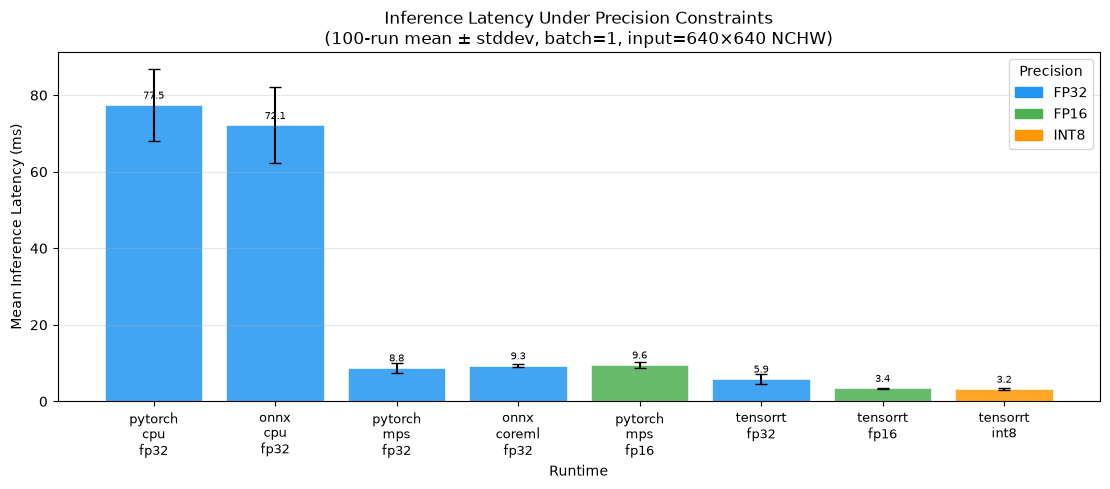

Saved: results/figures/latency_comparison.png


In [3]:
# ── Cell 3 ── Latency Bar Chart ───────────────────────────────────────────────
# Grouped by runtime, coloured by precision. Error bars show stddev.
# Framing: "Inference Latency Under Precision Constraints" (not "model speed").

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(max(8, len(runtimes) * 1.4), 5))
x = np.arange(len(runtimes))

bars = ax.bar(
    x, means, yerr=stds, capsize=4,
    color=[PRECISION_COLORS.get(p, "#9E9E9E") for p in precisions],
    alpha=0.85, edgecolor="white", linewidth=0.5,
)

# Annotate bar tops with mean value
for bar, val in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + max(stds) * 0.1,
        f"{val:.1f}", ha="center", va="bottom", fontsize=7.5,
    )

ax.set_xticks(x)
ax.set_xticklabels([r.replace("_", "\n") for r in runtimes], fontsize=9)
ax.set_ylabel("Mean Inference Latency (ms)")
ax.set_xlabel("Runtime")
ax.set_title(
    "Inference Latency Under Precision Constraints\n"
    "(100-run mean ± stddev, batch=1, input=640×640 NCHW)"
)
ax.grid(axis="y", alpha=0.3)

legend_patches = [
    mpatches.Patch(color=PRECISION_COLORS[p], label=PRECISION_LABELS[p])
    for p in PRECISION_LABELS
]
ax.legend(handles=legend_patches, title="Precision")

plt.tight_layout()
out_path = FIGURES_DIR / "latency_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [4]:
# ── Cell 4 ── mAP Accuracy Delta Table ───────────────────────────────────────
# Accuracy cost at each precision level per runtime.
# Delta is relative to FP32 baseline of the same runtime — never cross-runtime.
# Negative delta = accuracy degradation under quantisation constraints.

map_table = df_sorted[[
    "runtime", "precision", "hardware_label",
    "map_50_95", "map_50", "map_delta_vs_fp32",
]].copy()
map_table.columns = ["Runtime", "Precision", "Hardware", "mAP@50:95", "mAP@50", "Δ vs FP32"]

def fmt_delta(v):
    import math
    if math.isnan(v):
        return "  N/A"
    return f"{v:+.4f}"

print("=== Accuracy Degradation Under Quantisation Constraints ===")
print("(Δ vs FP32: negative = accuracy cost of quantisation for this runtime)")
print()

for _, row in map_table.iterrows():
    print(
        f"  {row['Runtime']:30s}  {row['Precision']:6s}  "
        f"mAP@50:95={row['mAP@50:95']:.4f}  "
        f"mAP@50={row['mAP@50']:.4f}  "
        f"Δ={fmt_delta(row['Δ vs FP32'])}"
    )

=== Accuracy Degradation Under Quantisation Constraints ===
(Δ vs FP32: negative = accuracy cost of quantisation for this runtime)

  pytorch_cpu_fp32                fp32    mAP@50:95=0.3595  mAP@50=0.5062  Δ=+0.0000
  onnx_cpu_fp32                   fp32    mAP@50:95=0.3595  mAP@50=0.5062  Δ=+0.0000
  pytorch_mps_fp32                fp32    mAP@50:95=0.3576  mAP@50=0.5029  Δ=+0.0000
  onnx_coreml_fp32                fp32    mAP@50:95=0.3576  mAP@50=0.5028  Δ=+0.0000
  pytorch_mps_fp16                fp16    mAP@50:95=0.3577  mAP@50=0.5031  Δ=+0.0001
  tensorrt_fp32                   fp32    mAP@50:95=0.3576  mAP@50=0.5029  Δ=+0.0000
  tensorrt_fp16                   fp16    mAP@50:95=0.3571  mAP@50=0.5029  Δ=-0.0004
  tensorrt_int8                   int8    mAP@50:95=0.2919  mAP@50=0.4208  Δ=-0.0657


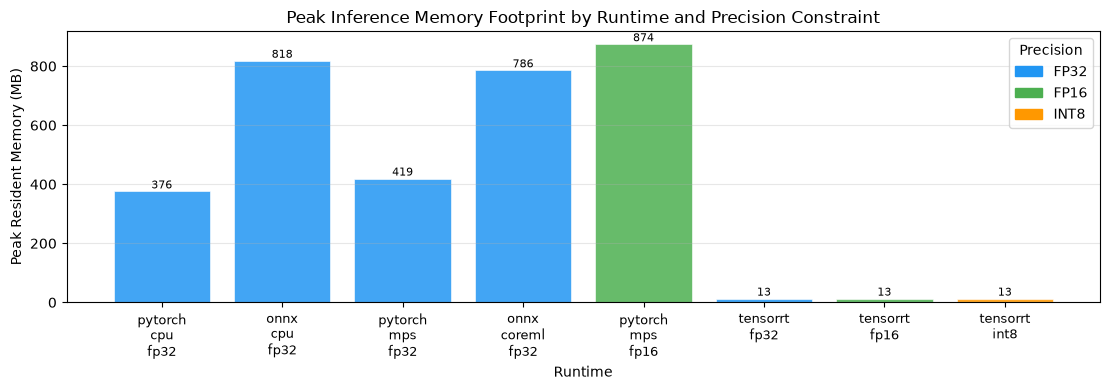

Saved: results/figures/memory_footprint.png


In [5]:
# ── Cell 5 ── Memory Footprint Comparison ─────────────────────────────────────
# Peak resident memory during inference, in MB.
# Shows memory budget required per runtime × precision combination.
# CPU runtimes measured via psutil RSS; GPU runtimes via torch.cuda.max_memory_allocated.

fig, ax = plt.subplots(figsize=(max(8, len(runtimes) * 1.4), 4))
x = np.arange(len(runtimes))
peak_mb = df_sorted["peak_memory_mb"].tolist()

bars = ax.bar(
    x, peak_mb,
    color=[PRECISION_COLORS.get(p, "#9E9E9E") for p in precisions],
    alpha=0.85, edgecolor="white", linewidth=0.5,
)

for bar, val in zip(bars, peak_mb):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
        f"{val:.0f}", ha="center", va="bottom", fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels([r.replace("_", "\n") for r in runtimes], fontsize=9)
ax.set_ylabel("Peak Resident Memory (MB)")
ax.set_xlabel("Runtime")
ax.set_title("Peak Inference Memory Footprint by Runtime and Precision Constraint")
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_patches, title="Precision")

plt.tight_layout()
out_path = FIGURES_DIR / "memory_footprint.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

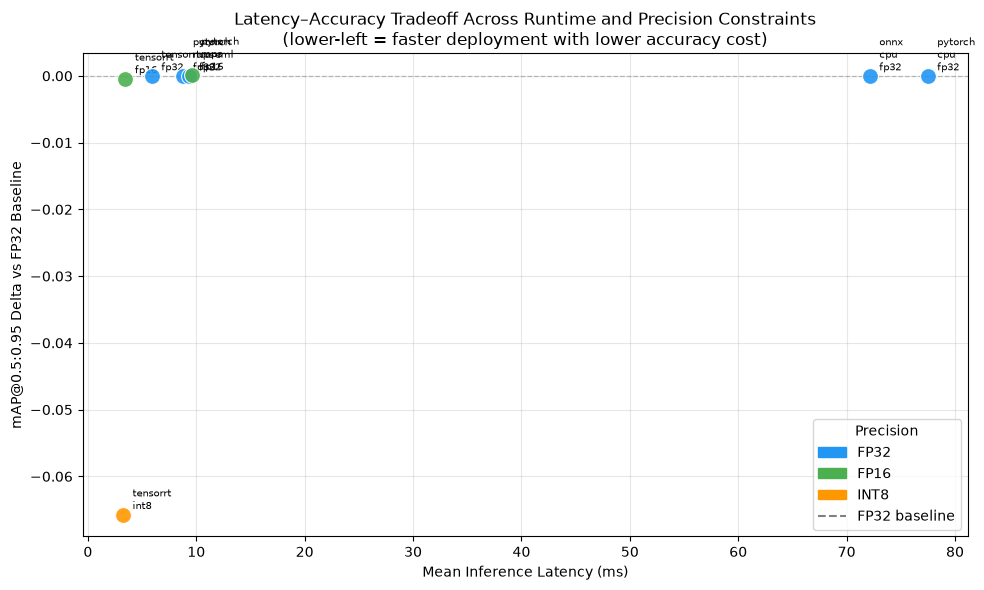

Saved: results/figures/tradeoff_scatter.png


In [6]:
# ── Cell 6 ── Latency–Accuracy Tradeoff Scatter ───────────────────────────────
# The deployment decision chart: latency (x) vs mAP delta from FP32 baseline (y).
# Each point is one runtime × precision combination.
# Points toward the origin (low latency, low accuracy cost) are deployment-optimal.
# FP32 points sit at delta=0 by definition — they anchor each runtime's baseline.

import math

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in df_sorted.iterrows():
    x_val = row["mean_latency_ms"]
    y_val = row["map_delta_vs_fp32"]

    if math.isnan(y_val):
        continue  # skip results without a valid baseline

    color = PRECISION_COLORS.get(row["precision"], "#9E9E9E")
    ax.scatter(x_val, y_val, color=color, s=130, zorder=5, alpha=0.9,
               edgecolors="white", linewidths=0.8)

    label = row["runtime"].replace("_", "\n")
    ax.annotate(
        label, (x_val, y_val),
        textcoords="offset points", xytext=(7, 4),
        fontsize=7.5,
    )

# FP32 baseline reference line
ax.axhline(0, color="gray", linewidth=0.9, linestyle="--", alpha=0.5,
           label="FP32 baseline (Δ=0)")

ax.set_xlabel("Mean Inference Latency (ms)")
ax.set_ylabel("mAP@0.5:0.95 Delta vs FP32 Baseline")
ax.set_title(
    "Latency–Accuracy Tradeoff Across Runtime and Precision Constraints\n"
    "(lower-left = faster deployment with lower accuracy cost)"
)
ax.grid(alpha=0.3)

all_legend = legend_patches + [plt.Line2D([0], [0], color="gray", linestyle="--", label="FP32 baseline")]
ax.legend(handles=all_legend, title="Precision")

plt.tight_layout()
out_path = FIGURES_DIR / "tradeoff_scatter.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [7]:
# ── Cell 7 ── Export Chart Inventory ──────────────────────────────────────────
# All charts were saved in Cells 3, 5, and 6.
# This cell provides a final inventory and generates README embed snippets.

print("=== Exported Figures ===")
figures = sorted(FIGURES_DIR.glob("*.png"))
for f in figures:
    size_kb = f.stat().st_size / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

print(f"\n{len(figures)} figures exported to: {FIGURES_DIR}")
print("\nREADME embed snippets:")
for f in figures:
    rel = f.relative_to(Path("."))
    print(f'  ![{f.stem.replace("_", " ").title()}]({rel})')

print("\nCommit figures to the repo so they render in GitHub:")
print("  git add results/figures/")
print("  git commit -m 'feat(results): add benchmark analysis figures'")

=== Exported Figures ===
  results/figures/latency_comparison.png  (64.4 KB)
  results/figures/latency_comparison_pre_letterbox_fix_20260810.png  (64.4 KB)
  results/figures/memory_footprint.png  (57.0 KB)
  results/figures/memory_footprint_pre_letterbox_fix_20260810.png  (57.0 KB)
  results/figures/tradeoff_scatter.png  (73.4 KB)
  results/figures/tradeoff_scatter_pre_letterbox_fix_20260810.png  (73.4 KB)

6 figures exported to: results/figures

README embed snippets:
  ![Latency Comparison](results/figures/latency_comparison.png)
  ![Latency Comparison Pre Letterbox Fix 20260810](results/figures/latency_comparison_pre_letterbox_fix_20260810.png)
  ![Memory Footprint](results/figures/memory_footprint.png)
  ![Memory Footprint Pre Letterbox Fix 20260810](results/figures/memory_footprint_pre_letterbox_fix_20260810.png)
  ![Tradeoff Scatter](results/figures/tradeoff_scatter.png)
  ![Tradeoff Scatter Pre Letterbox Fix 20260810](results/figures/tradeoff_scatter_pre_letterbox_fix_20260810.p